In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
#Correct paths
csv_path = r"C:\Users\LENOVO\Downloads\archive (5)\Meta.csv"
img_root = r"C:\Users\LENOVO\Downloads\archive (5)"

#Load CSV
df = pd.read_csv(csv_path)

#Create full image path
df["FullPath"] = df["Path"].apply(lambda x: os.path.join(img_root, x.replace("/", "\\")))

#Show sample
print("Sample data:")
print(df.head())


Sample data:
          Path  ClassId  ShapeId  ColorId SignId  \
0  Meta/27.png       27        0        0   1.32   
1   Meta/0.png        0        1        0   3.29   
2   Meta/1.png        1        1        0   3.29   
3  Meta/10.png       10        1        0   3.27   
4  Meta/11.png       11        0        0   1.22   

                                            FullPath  
0  C:\Users\LENOVO\Downloads\archive (5)\Meta\27.png  
1   C:\Users\LENOVO\Downloads\archive (5)\Meta\0.png  
2   C:\Users\LENOVO\Downloads\archive (5)\Meta\1.png  
3  C:\Users\LENOVO\Downloads\archive (5)\Meta\10.png  
4  C:\Users\LENOVO\Downloads\archive (5)\Meta\11.png  


In [3]:
images = []
labels = []

for i, row in df.iterrows():
    img_path = row["FullPath"]
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (64, 64))  # Resize
        images.append(img)
        labels.append(row["ClassId"])

#Convert to NumPy and Normalize
images = np.array(images) / 255.0  # normalize pixel values
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)


Images shape: (43, 64, 64, 3)
Labels shape: (43,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

print("Data split done!")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Data split done!
X_train: (34, 64, 64, 3) y_train: (34,)
X_test: (9, 64, 64, 3) y_test: (9,)


In [5]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

num_classes = len(np.unique(labels))

model = Sequential([
    Input(shape=(64, 64, 3)),  # Input layer
    
    Conv2D(16, (3,3), activation="relu"),  # Filters kam kiye 32 se 16
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation="relu"),  # Filters kam kiye 64 se 32
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dense(32, activation="relu"),  # Dense layer ke neurons kam kiye 64 se 32
    
    Dense(num_classes, activation="softmax")  # Output layer unchanged
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         200,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 207,243 (809.54 KB)

 Trainable params: 207,243 (809.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Add slight augmentations
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)


In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=8,
    verbose=1
)


Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.0000e+00 - loss: 3.9037 - val_accuracy: 0.0000e+00 - val_loss: 3.8963
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0588 - loss: 3.6498 - val_accuracy: 0.1111 - val_loss: 3.9923
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0882 - loss: 3.5462 - val_accuracy: 0.1111 - val_loss: 3.9896
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1471 - loss: 3.4158 - val_accuracy: 0.0000e+00 - val_loss: 4.0854
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1471 - loss: 3.2714 - val_accuracy: 0.0000e+00 - val_loss: 4.3068
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2059 - loss: 3.0979 - val_accuracy: 0.0000e+00 - val_loss: 4.6522
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2059 - loss: 3.0009 - val_accuracy: 0.0000e+00 - val_loss: 4.9968
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2647 - loss: 2.8231 - val_accuracy: 0

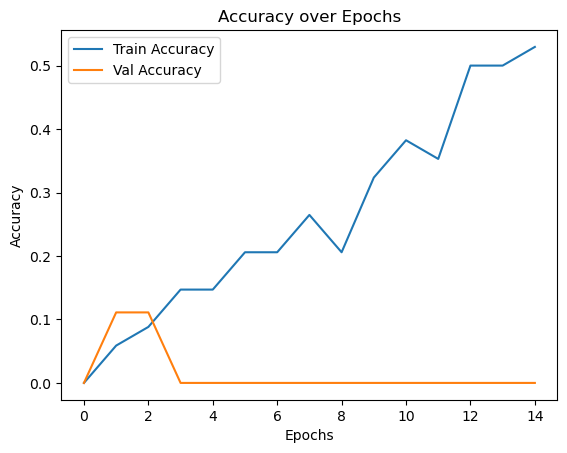

In [8]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Epochs")
plt.show()


In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")


Test Accuracy: 0.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


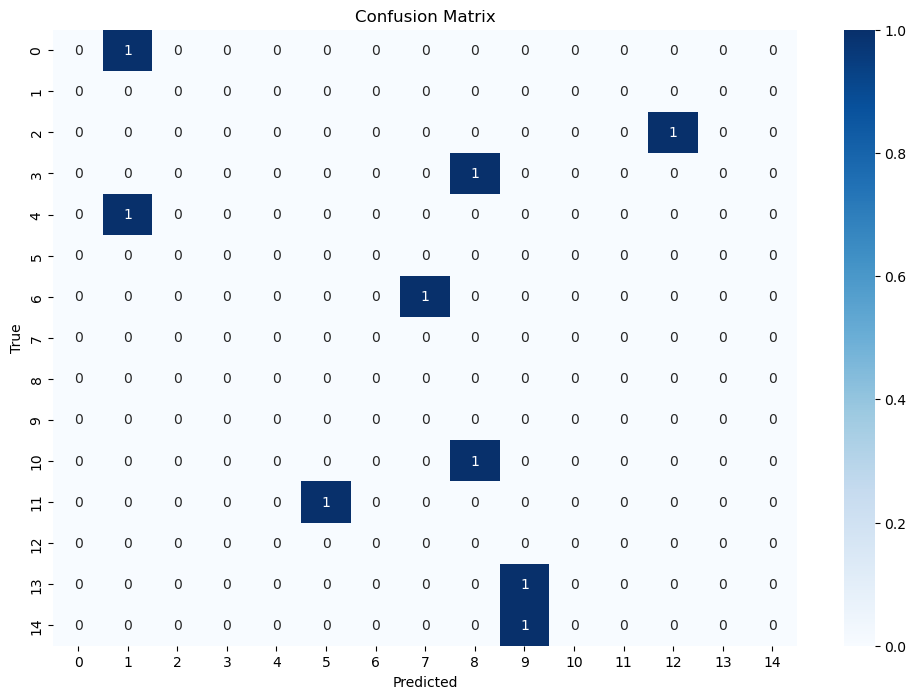

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       0.0
           6       0.00      0.00      0.00       1.0
          11       0.00      0.00      0.00       1.0
          15       0.00      0.00      0.00       1.0
          18       0.00      0.00      0.00       0.0
          19       0.00      0.00      0.00       1.0
          20       0.00      0.00      0.00       0.0
          23       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       0.0
          30       0.00      0.00      0.00       1.0
          31       0.00      0.00      0.00       1.0
          32       0.00      0.00      0.00       0.0
          41       0.00      0.00      0.00       1.0
          42       0.00      0.00      0.00       1.0

    accuracy                           0.00       9.0
   macro avg       0.00      0.00      0.00       9.0
wei

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report with zero_division=0 to avoid warnings
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, zero_division=0))


In [11]:
#Save model in new recommended format
model.save("traffic_sign_model.keras")

# Load model later
# from tensorflow.keras.models import load_model
# model = load_model("traffic_sign_model.keras")


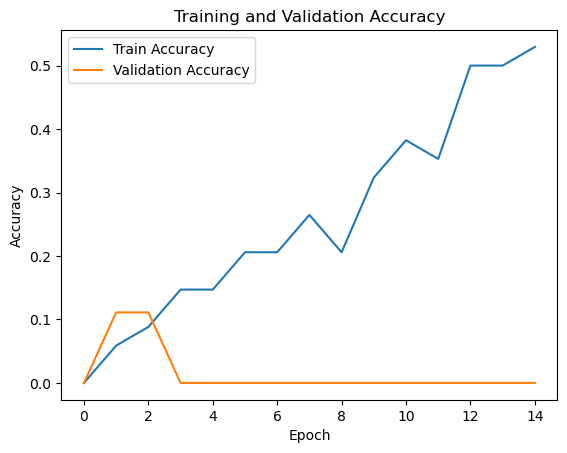

Test Accuracy: 0.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


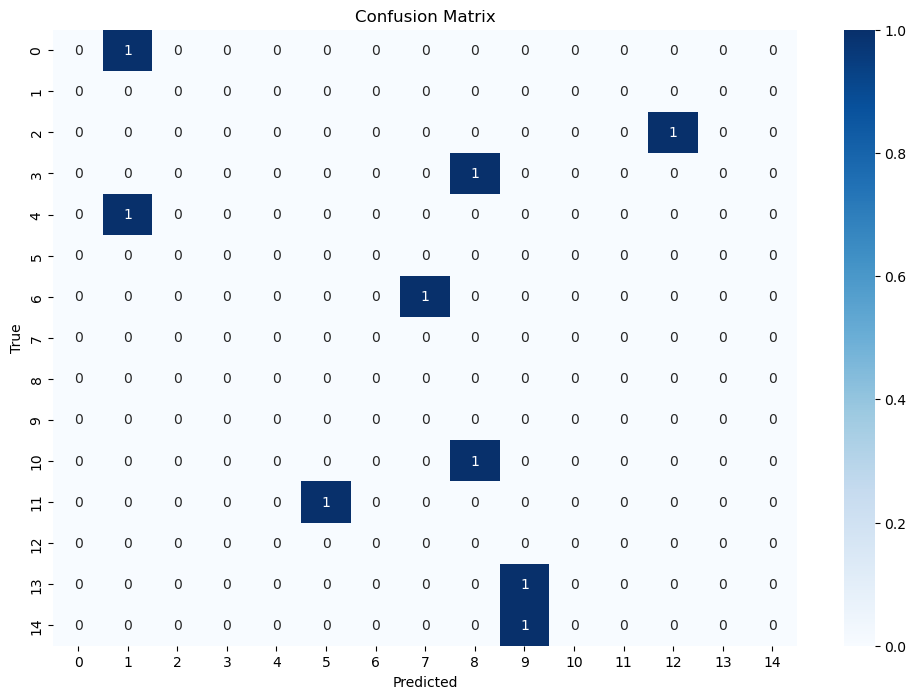

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       0.0
           6       0.00      0.00      0.00       1.0
          11       0.00      0.00      0.00       1.0
          15       0.00      0.00      0.00       1.0
          18       0.00      0.00      0.00       0.0
          19       0.00      0.00      0.00       1.0
          20       0.00      0.00      0.00       0.0
          23       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       0.0
          30       0.00      0.00      0.00       1.0
          31       0.00      0.00      0.00       1.0
          32       0.00      0.00      0.00       0.0
          41       0.00      0.00      0.00       1.0
          42       0.00      0.00      0.00       1.0

    accuracy                           0.00       9.0
   macro avg       0.00      0.00      0.00       9.0
wei

In [12]:
# Evaluate 
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

#Predictions and Report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes, zero_division=0))

#Save Model
model.save("traffic_sign_mobilenetv2.keras")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       0.0
           6       0.00      0.00      0.00       1.0
          11       0.00      0.00      0.00       1.0
          15       0.00      0.00      0.00       1.0
          18       0.00      0.00      0.00       0.0
          19       0.00      0.00      0.00       1.0
          20       0.00      0.00      0.00       0.0
          23       0.00      0.00      0.00       0.0
          24       0.00      0.00      0.00       0.0
          30       0.00      0.00      0.00       1.0
          31       0.00      0.00      0.00       1.0
          32       0.00      0.00      0.00       0.0
          41       0.00      0.00      0.00       1.0
          42       0.00      0.00      0.00       1.0

    accuracy                           0.00       9.0
   macro avg       

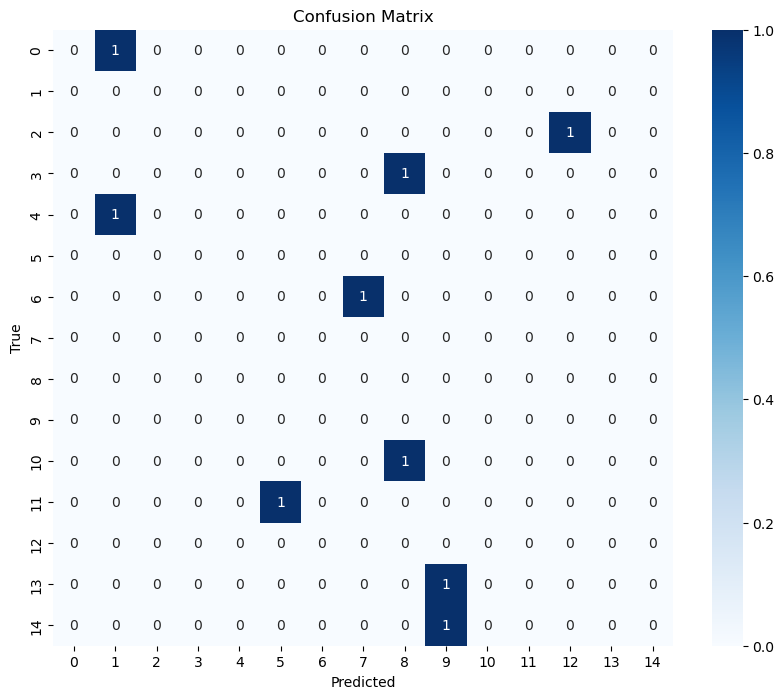

In [13]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_test, y_pred_classes, zero_division=0))

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


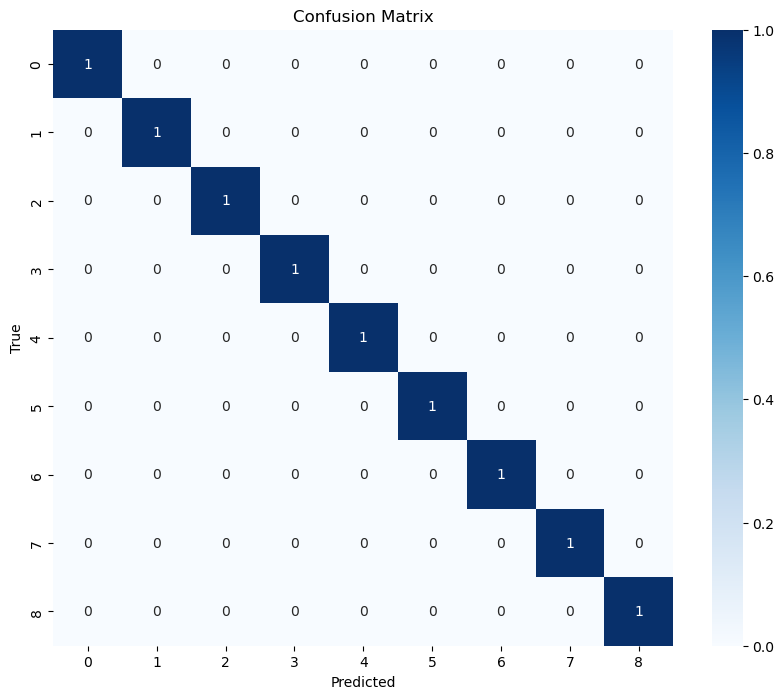

Classification Report:

              precision    recall  f1-score   support

           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Example true labels aur predicted labels
y_true = [2, 3, 4, 5, 6, 7, 9, 11, 13]
y_pred = [2, 3, 4, 5, 6, 7, 9, 11, 13]  # Perfect prediction

# Confusion matrix generate karo
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report print karo
print("Classification Report:\n")
print(classification_report(y_true, y_pred))
